In [1]:
import seaborn as sns
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
events_df = sb.competition_events(
country="Germany",
division="1. Bundesliga",
season="2023/2024",
gender="male")
frames_df = sb.competition_frames(
country="Germany",
division="1. Bundesliga",
season="2023/2024",
gender="male")

frames_df.rename(columns={'event_uuid': 'id'}, inplace = True)
merged_df=pd.merge(frames_df, events_df,
how="left", on=["match_id","id"]) 

/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbomb

In [2]:
# Print column names for events_df
print("Column names in events_df:")
for col in events_df.columns:
    print(col)

# Print column names for frames_df
print("Column names in frames_df:")
for col in frames_df.columns:
    print(col)

Column names in events_df:
50_50
bad_behaviour_card
ball_receipt_outcome
ball_recovery_offensive
ball_recovery_recovery_failure
block_deflection
block_offensive
block_save_block
carry_end_location
clearance_aerial_won
clearance_body_part
clearance_head
clearance_left_foot
clearance_other
clearance_right_foot
counterpress
dribble_no_touch
dribble_nutmeg
dribble_outcome
dribble_overrun
duel_outcome
duel_type
duration
foul_committed_advantage
foul_committed_card
foul_committed_offensive
foul_committed_penalty
foul_committed_type
foul_won_advantage
foul_won_defensive
foul_won_penalty
goalkeeper_body_part
goalkeeper_end_location
goalkeeper_outcome
goalkeeper_position
goalkeeper_punched_out
goalkeeper_shot_saved_off_target
goalkeeper_shot_saved_to_post
goalkeeper_success_in_play
goalkeeper_success_out
goalkeeper_technique
goalkeeper_type
id
index
injury_stoppage_in_chain
interception_outcome
location
match_id
minute
miscontrol_aerial_won
off_camera
out
pass_aerial_won
pass_angle
pass_assiste

In [3]:
import matplotlib.pyplot as plt

In [5]:
# Define the list of event types to include
touches = [
    'Shot', 'Foul Won', 'Miscontrol', 'Ball Receipt*', 'Carry', 
    'Block', 'Clearance', 'Duel'
]

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_86137/3112969496.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(


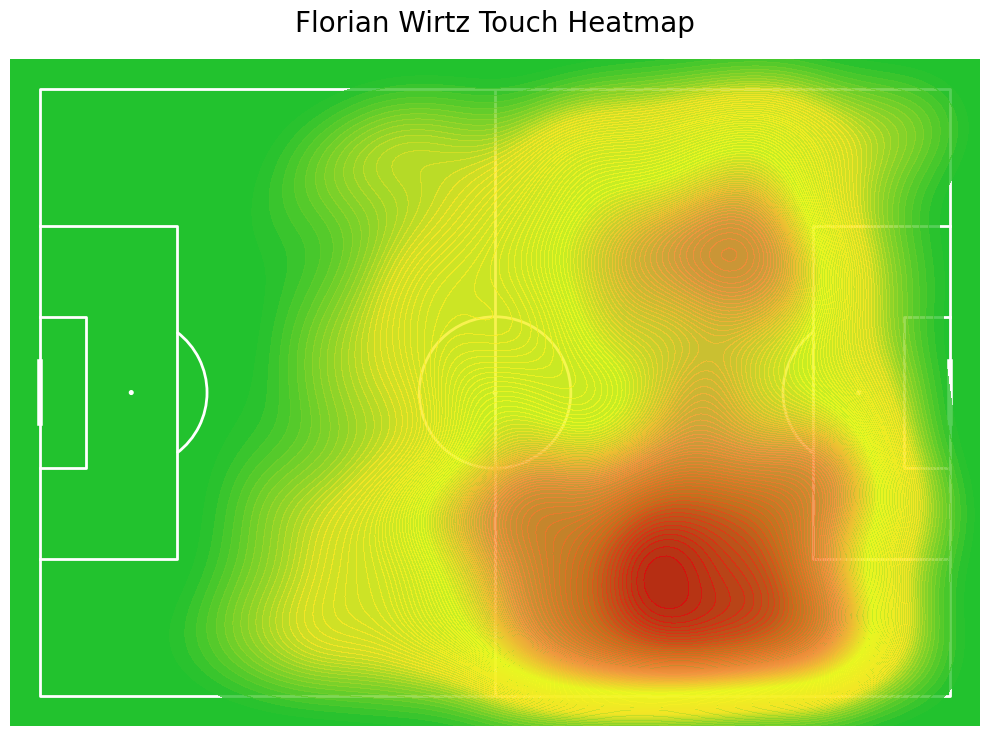

In [10]:


# Filter events for 'Florian Wirtz'
wirtz_events = events_df[
    (events_df['player'] == 'Florian Wirtz') & 
    (events_df['type'].isin(touches))
]

# Extract locations of touches
touch_locations = wirtz_events['location'].dropna().tolist()

# Separate x and y coordinates
x_coords = [loc[0] for loc in touch_locations]
y_coords = [loc[1] for loc in touch_locations]

# Set up the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white', stripe=False)
fig, ax = pitch.draw(figsize=(12, 8))

# Create custom colormap
colors = ['#22c22e', '#fde725', '#f0f921', '#f89540', '#e8601c', '#dc050c']
n_bins = 256
cmap = plt.cm.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# KDE plot parameters
kde = sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap=cmap,
    shade=True,
    cbar=False,
    ax=ax,
    zorder=2,
    alpha=0.8,  # Increased alpha for more vibrant colors
    levels=100,  # Increased levels for smoother gradients
    thresh=0.03  # Lowered thresh to show more of the heatmap
)

# Flip the y-axis
ax.invert_yaxis()

# Remove axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# Add title
ax.set_title('Florian Wirtz Touch Heatmap', fontsize=20, pad=20)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_86137/3411115497.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(


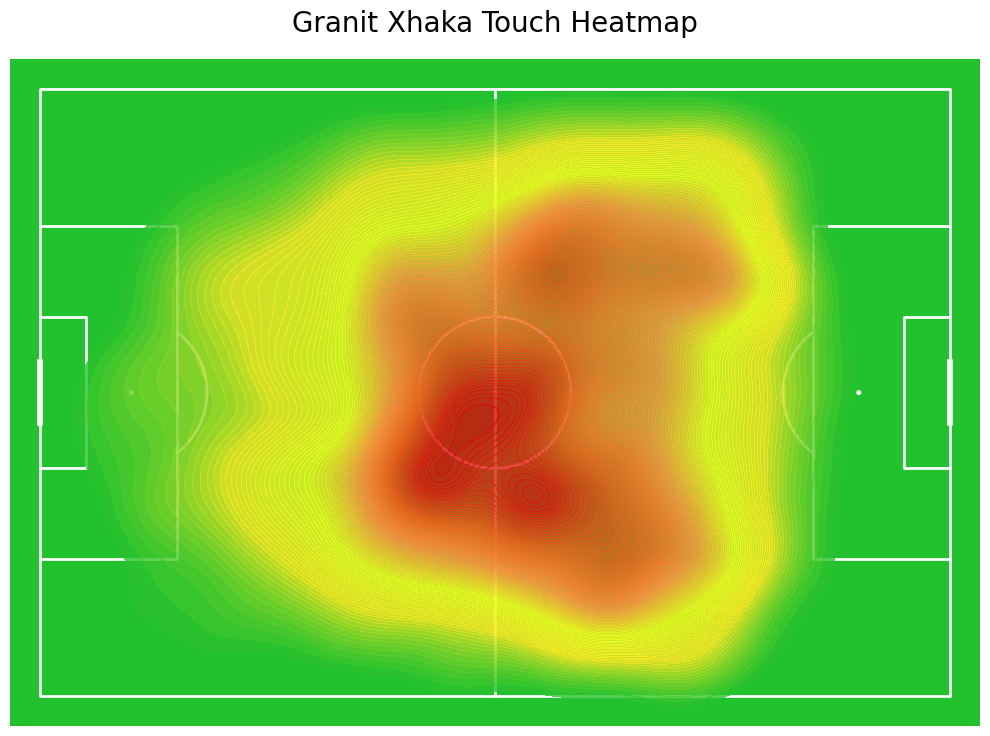

In [12]:


# Filter events for 'Granit Xhaka'
xhaka_events = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['type'].isin(touches))
]

# Extract locations of touches
touch_locations = xhaka_events['location'].dropna().tolist()

# Separate x and y coordinates
x_coords = [loc[0] for loc in touch_locations]
y_coords = [loc[1] for loc in touch_locations]

# Set up the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white', stripe=False)
fig, ax = pitch.draw(figsize=(12, 8))

# Create custom colormap
colors = ['#22c22e', '#fde725', '#f0f921', '#f89540', '#e8601c', '#dc050c']
n_bins = 256
cmap = plt.cm.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# KDE plot parameters
kde = sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap=cmap,
    shade=True,
    cbar=False,
    ax=ax,
    zorder=2,
    alpha=0.8,  # Increased alpha for more vibrant colors
    levels=100,  # Increased levels for smoother gradients
    thresh=0.03  # Lowered thresh to show more of the heatmap
)

# Flip the y-axis
ax.invert_yaxis()

# Remove axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# Add title
ax.set_title('Granit Xhaka Touch Heatmap', fontsize=20, pad=20)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

type
Ball Receipt*    3098
Carry            2771
Duel               69
Block              65
Foul Won           49
Clearance          46
Shot               44
Miscontrol         23
Name: count, dtype: int64


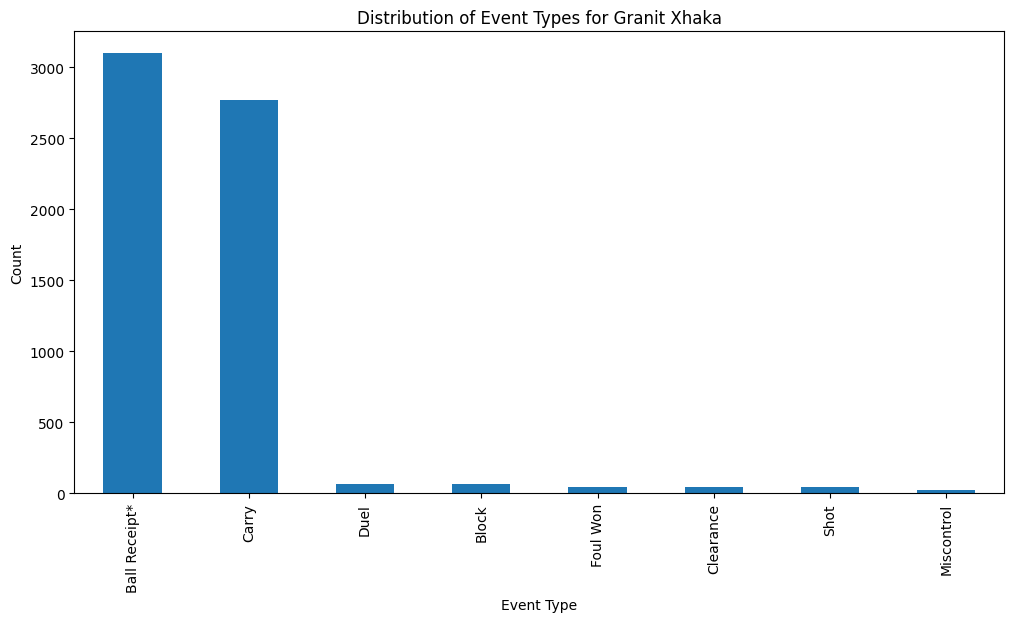

In [13]:
# Count the number of each event type for Granit Xhaka
event_counts = xhaka_events['type'].value_counts()
print(event_counts)

# Plot the distribution of event types
event_counts.plot(kind='bar', figsize=(12, 6), title='Distribution of Event Types for Granit Xhaka')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()

In [ ]:
# Filter events for 'Granit Xhaka'
xhaka_events = events_df[events_df['player'] == 'Granit Xhaka']

# Filter for pass events
passes = xhaka_events[xhaka_events['type'] == 'Pass']

# Check if any pass events are found
if passes.empty:
    print("No pass events found for Granit Xhaka.")
else:
    print(f"Number of pass events found: {passes.shape[0]}")
    print(passes.head())


Number of pass events found: 3299
    50_50 bad_behaviour_card ball_receipt_outcome ball_recovery_offensive  \
221   NaN                NaN                  NaN                     NaN   
230   NaN                NaN                  NaN                     NaN   
232   NaN                NaN                  NaN                     NaN   
243   NaN                NaN                  NaN                     NaN   
248   NaN                NaN                  NaN                     NaN   

    ball_recovery_recovery_failure block_deflection block_offensive  \
221                            NaN              NaN             NaN   
230                            NaN              NaN             NaN   
232                            NaN              NaN             NaN   
243                            NaN              NaN             NaN   
248                            NaN              NaN             NaN   

    block_save_block carry_end_location clearance_aerial_won  ...  \
221    

In [ ]:
  # Calculate pass accuracy
total_passes = passes.shape[0]
successful_passes = passes[passes['pass_outcome'].isna()].shape[0]
pass_accuracy = successful_passes / total_passes * 100
print(f"Pass Accuracy: {pass_accuracy:.2f}%")


Pass Accuracy: 92.30%


In [ ]:
# Calculate total passes
total_passes = passes.shape[0]

# Calculate successful passes
successful_passes = passes[passes['pass_outcome'].isna()].shape[0]

# Calculate unsuccessful passes
unsuccessful_passes = passes[~passes['pass_outcome'].isna()].shape[0]

# Calculate pass accuracy
if total_passes > 0:
    pass_accuracy = successful_passes / total_passes * 100
    unsuccessful_pass_percentage = unsuccessful_passes / total_passes * 100
    print(f"Pass Accuracy: {pass_accuracy:.2f}%")
    print(f"Unsuccessful Pass Percentage: {unsuccessful_pass_percentage:.2f}%")
else:
    print("No pass events found for Granit Xhaka.")

Pass Accuracy: 92.30%
Unsuccessful Pass Percentage: 7.70%


In [ ]:
# Filter events for 'Granit Xhaka'
xhaka_events = events_df[events_df['player'] == 'Granit Xhaka']

# Get unique match IDs
unique_match_ids = xhaka_events['match_id'].unique()

# Print unique match IDs
print("Unique match IDs for Granit Xhaka:")
print(unique_match_ids)

# Print the number of unique matches
print(f"Number of unique matches: {len(unique_match_ids)}")

Unique match IDs for Granit Xhaka:
[3895302 3895292 3895333 3895340 3895348 3895286 3895220 3895250 3895266
 3895275 3895180 3895134 3895121 3895107 3895074 3895139 3895086 3895309
 3895258 3895244 3895232 3895210 3895202 3895194 3895182 3895167 3895158
 3895153 3895113 3895095 3895067 3895060 3895052]
Number of unique matches: 33


In [ ]:
   opponents = {}

In [ ]:
   for match_id in unique_match_ids:
       # Filter events for the specific match
       match_events = events_df[events_df['match_id'] == match_id]
       
       # Get the teams involved in the match
       teams = match_events['team'].unique()
       
       # Identify Xhaka's team
       xhaka_team = xhaka_events[xhaka_events['match_id'] == match_id]['team'].iloc[0]
       
       # Identify the opponent team
       opponent_team = [team for team in teams if team != xhaka_team][0]
       
       # Store the opponent team in the dictionary
       opponents[match_id] = opponent_team

In [ ]:
   print("Opponents for each match Granit Xhaka played in:")
   for match_id, opponent in opponents.items():
       print(f"Match ID: {match_id}, Opponent: {opponent}")

Opponents for each match Granit Xhaka played in:
Match ID: 3895302, Opponent: Werder Bremen
Match ID: 3895292, Opponent: Union Berlin
Match ID: 3895333, Opponent: Eintracht Frankfurt
Match ID: 3895340, Opponent: Bochum
Match ID: 3895348, Opponent: Augsburg
Match ID: 3895286, Opponent: Hoffenheim
Match ID: 3895220, Opponent: Darmstadt 98
Match ID: 3895250, Opponent: FSV Mainz 05
Match ID: 3895266, Opponent: Wolfsburg
Match ID: 3895275, Opponent: Freiburg
Match ID: 3895180, Opponent: Eintracht Frankfurt
Match ID: 3895134, Opponent: Hoffenheim
Match ID: 3895121, Opponent: Freiburg
Match ID: 3895107, Opponent: FC Köln
Match ID: 3895074, Opponent: Bayern Munich
Match ID: 3895139, Opponent: Union Berlin
Match ID: 3895086, Opponent: FC Heidenheim
Match ID: 3895309, Opponent: Borussia Dortmund
Match ID: 3895258, Opponent: FC Köln
Match ID: 3895244, Opponent: FC Heidenheim
Match ID: 3895232, Opponent: Bayern Munich
Match ID: 3895210, Opponent: Borussia Mönchengladbach
Match ID: 3895202, Opponen

In [16]:
   if 'x' not in events_df.columns:
       events_df[['x', 'y']] = events_df['location'].apply(pd.Series)

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/3769400664.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['x', 'y']] = events_df['location'].apply(pd.Series)
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/3769400664.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['x', 'y']] = events_df['location'].apply(pd.Series)


In [17]:
   if 'pass_end_x' not in events_df.columns:
       events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/807102536.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/807102536.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)


In [18]:
   xhaka_f3rd_passes = events_df[
       (events_df['player'] == 'Granit Xhaka') & 
       (events_df['type'] == "Pass") & 
       (events_df['x'] < 80) & 
       (events_df['pass_end_x'] > 80)
   ]

In [19]:
xhaka_f3rd_passes_count = xhaka_f3rd_passes.shape[0]

In [20]:
print(f"Number of final third passes by Granit Xhaka: {xhaka_f3rd_passes_count}")

Number of final third passes by Granit Xhaka: 419


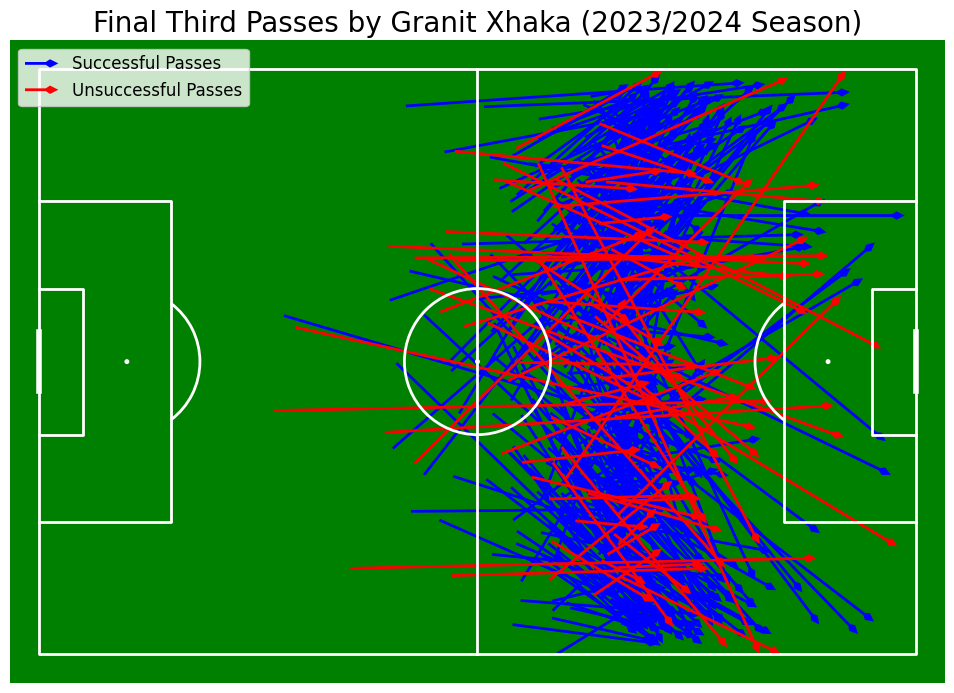

In [21]:
# Plot final third passes on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot successful passes
successful_passes = xhaka_f3rd_passes[xhaka_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(successful_passes['x'], successful_passes['y'],
             successful_passes['pass_end_x'], successful_passes['pass_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Successful Passes')

# Plot unsuccessful passes
unsuccessful_passes = xhaka_f3rd_passes[~xhaka_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(unsuccessful_passes['x'], unsuccessful_passes['y'],
             unsuccessful_passes['pass_end_x'], unsuccessful_passes['pass_end_y'],
             ax=ax, color='red', width=2, headwidth=3, headlength=3, label='Unsuccessful Passes')

# Add title and legend
ax.set_title('Final Third Passes by Granit Xhaka (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [22]:
   wirtz_f3rd_passes = events_df[
       (events_df['player'] == 'Florian Wirtz') & 
       (events_df['type'] == "Pass") & 
       (events_df['x'] < 80) & 
       (events_df['pass_end_x'] > 80)
   ]

In [23]:
wirtz_f3rd_passes_count = wirtz_f3rd_passes.shape[0]
print(f"Number of final third passes by Florian Wirtz: {wirtz_f3rd_passes_count}")

Number of final third passes by Florian Wirtz: 153


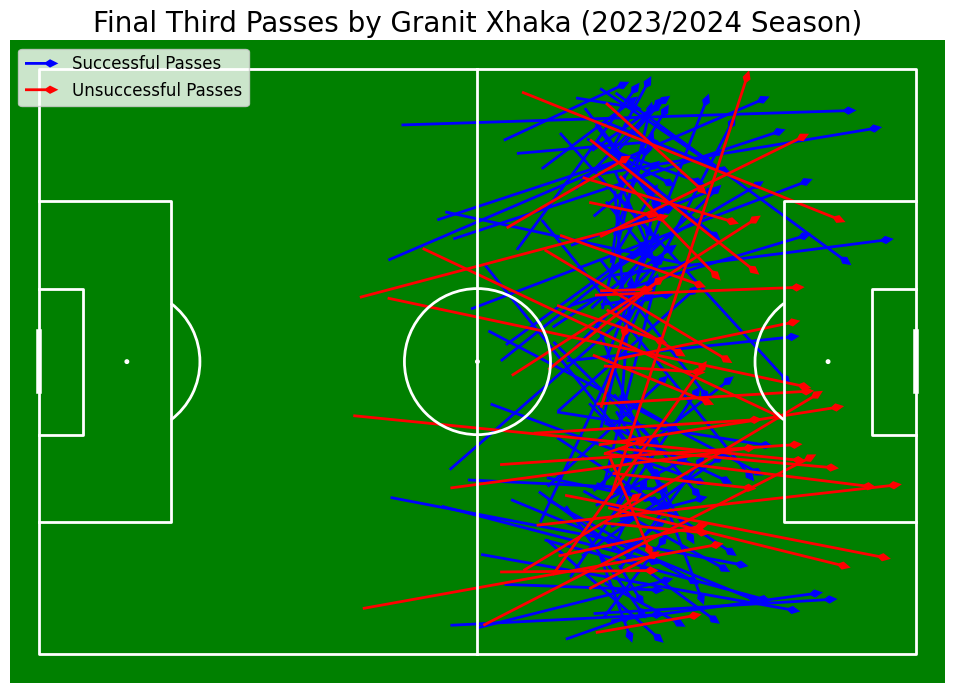

In [24]:
# Plot final third passes on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot successful passes
successful_passes = wirtz_f3rd_passes[wirtz_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(successful_passes['x'], successful_passes['y'],
             successful_passes['pass_end_x'], successful_passes['pass_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Successful Passes')

# Plot unsuccessful passes
unsuccessful_passes = wirtz_f3rd_passes[~wirtz_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(unsuccessful_passes['x'], unsuccessful_passes['y'],
             unsuccessful_passes['pass_end_x'], unsuccessful_passes['pass_end_y'],
             ax=ax, color='red', width=2, headwidth=3, headlength=3, label='Unsuccessful Passes')

# Add title and legend
ax.set_title('Final Third Passes by Granit Xhaka (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter for carries by Granit Xhaka that start before the final third and end in the final third
xhaka_final_third_carries = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of such carries by Granit Xhaka
xhaka_final_third_carry_count = xhaka_final_third_carries.shape[0]

# Display the result
print(f"Number of final third carries by Granit Xhaka: {xhaka_final_third_carry_count}")

Number of final third carries by Granit Xhaka: 63


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_80401/2851064281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_80401/2851064281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if is

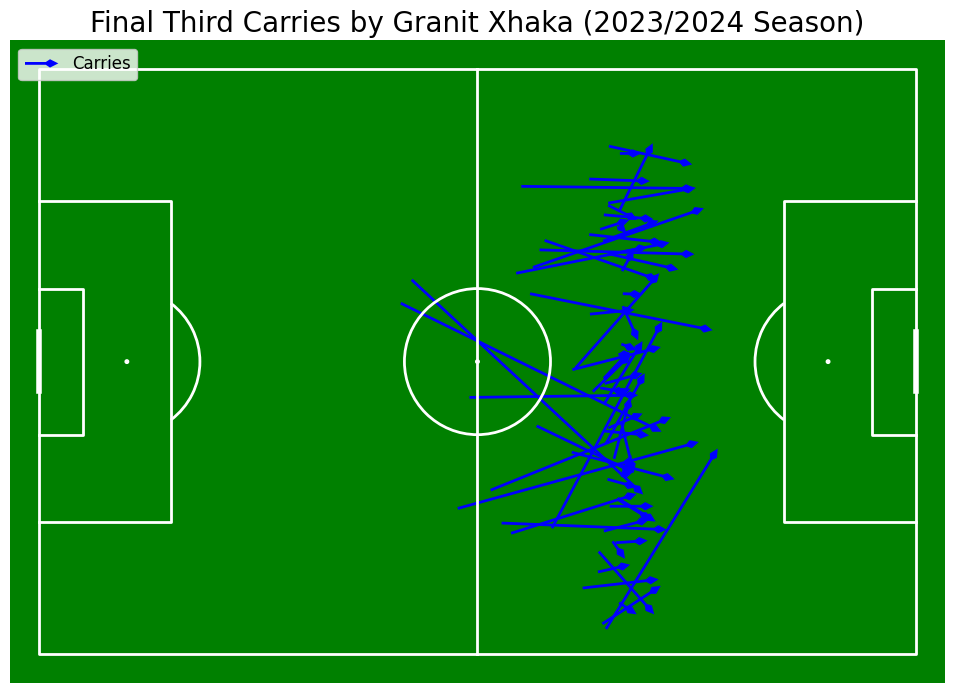

In [ ]:
# Plot final third carries on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot carries
pitch.arrows(xhaka_final_third_carries['x'], xhaka_final_third_carries['y'],
             xhaka_final_third_carries['carry_end_x'], xhaka_final_third_carries['carry_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Carries')

# Add title and legend
ax.set_title('Final Third Carries by Granit Xhaka (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [25]:
# Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter for carries by Granit Xhaka that start before the final third and end in the final third
wirtz_final_third_carries = events_df[
    (events_df['player'] == 'Florian Wirtz') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of such carries by Granit Xhaka
wirtz_final_third_carry_count = wirtz_final_third_carries.shape[0]

# Display the result
print(f"Number of final third carries by Florian Wirtz: {wirtz_final_third_carry_count}")

Number of final third carries by Florian Wirtz: 123


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/3217073779.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_83056/3217073779.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if is

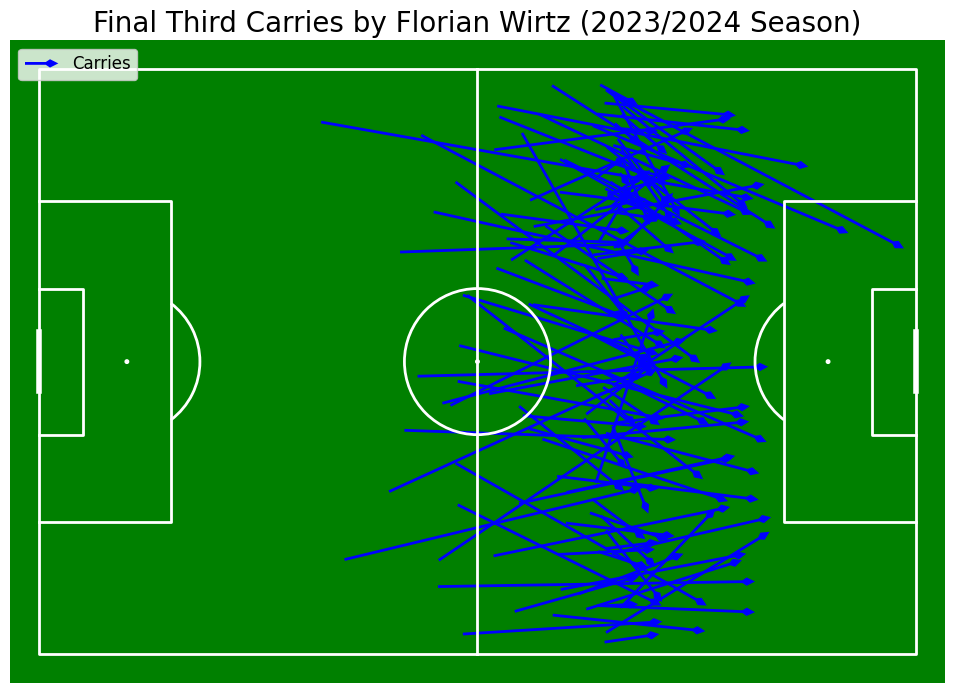

In [26]:
# Plot final third carries on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot carries
pitch.arrows(wirtz_final_third_carries['x'], wirtz_final_third_carries['y'],
             wirtz_final_third_carries['carry_end_x'], wirtz_final_third_carries['carry_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Carries')

# Add title and legend
ax.set_title('Final Third Carries by Florian Wirtz (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Filter passes in the final third
final_third_passes = events_df[
    (events_df['type'] == "Pass") & 
    (events_df['x'] < 80) & 
    (events_df['pass_end_x'] > 80)
]

# Count the number of final third passes by each player
final_third_passes_count = final_third_passes.groupby('player').size().reset_index(name='count')

# Display the results
print(final_third_passes_count)

                        player  count
0                  Adam Hložek      7
1                  Adrian Beck      7
2                Alassane Pléa      5
3    Alejandro Grimaldo García    127
4          Aleksandar Pavlović      8
..                         ...    ...
302                Xavi Simons      7
303           Yannick Gerhardt      7
304              Yannik Keitel      1
305      Yussuf Yurary Poulsen      1
306     Yvandro Borges Sanches      1

[307 rows x 2 columns]


In [ ]:
# Filter passes in the final third for Bayer Leverkusen players
final_third_passes = events_df[
    (events_df['type'] == "Pass") & 
    (events_df['x'] < 80) & 
    (events_df['pass_end_x'] > 80) & 
    (events_df['team'] == "Bayer Leverkusen")
]

# Count the number of final third passes by each player
final_third_passes_count = final_third_passes.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_final_third_passes_count = final_third_passes_count.sort_values(by='count', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_passes_count)

                            player  count
8                     Granit Xhaka    419
5            Edmond Fayçal Tapsoba    222
6      Exequiel Alejandro Palacios    184
12                    Jonathan Tah    174
18                 Odilon Kossonou    164
7                    Florian Wirtz    153
21                  Robert Andrich    143
1        Alejandro Grimaldo García    127
20     Piero Martín Hincapié Reyna    118
11                   Jonas Hofmann    108
13                  Josip Stanišić    106
10                Jeremie Frimpong     36
14                  Lukáš Hrádecký     31
2                       Amine Adli     28
22            Victor Okoh Boniface     24
16                    Nathan Tella     12
15                    Nadiem Amiri      8
19                   Patrik Schick      8
0                      Adam Hložek      7
9     Gustavo Adolfo Puerta Molano      4
3   Arthur Augusto de Matos Soares      4
17                     Noah Mbamba      3
4           Borja Iglesias Quintas

In [ ]:
 #Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter carries for Bayer Leverkusen players that start before the final third and end in the final third
final_third_carries = events_df[
    (events_df['team'] == 'Bayer Leverkusen') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of final third carries by each player
final_third_carry_count = final_third_carries.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_final_third_carry_count = final_third_carry_count.sort_values(by='count', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_carry_count)

                            player  count
7                    Florian Wirtz    123
10                Jeremie Frimpong     75
8                     Granit Xhaka     63
1        Alejandro Grimaldo García     60
11                   Jonas Hofmann     54
16                 Odilon Kossonou     51
5            Edmond Fayçal Tapsoba     51
18     Piero Martín Hincapié Reyna     45
13                  Josip Stanišić     43
20            Victor Okoh Boniface     31
6      Exequiel Alejandro Palacios     27
19                  Robert Andrich     25
2                       Amine Adli     23
12                    Jonathan Tah     19
15                    Nathan Tella     12
17                   Patrik Schick     11
0                      Adam Hložek      9
3   Arthur Augusto de Matos Soares      6
4           Borja Iglesias Quintas      3
14                    Nadiem Amiri      2
9     Gustavo Adolfo Puerta Molano      1


In [ ]:
# Merge the two counts on player name
final_third_progressions = pd.merge(final_third_passes_count, final_third_carry_count, on='player', how='outer', suffixes=('_passes', '_carries')).fillna(0)

# Sum the counts of passes and carries to get total progressions
final_third_progressions['total_progressions'] = final_third_progressions['count_passes'] + final_third_progressions['count_carries']

# Sort the results in descending order
sorted_final_third_progressions = final_third_progressions.sort_values(by='total_progressions', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_progressions)

# Display the total count of final third progressions
total_progressions_count = sorted_final_third_progressions['total_progressions'].sum()
print(f"Total final third progressions for Bayer Leverkusen players: {total_progressions_count}")

                            player  count_passes  count_carries  \
8                     Granit Xhaka           419           63.0   
7                    Florian Wirtz           153          123.0   
5            Edmond Fayçal Tapsoba           222           51.0   
18                 Odilon Kossonou           164           51.0   
6      Exequiel Alejandro Palacios           184           27.0   
12                    Jonathan Tah           174           19.0   
1        Alejandro Grimaldo García           127           60.0   
21                  Robert Andrich           143           25.0   
20     Piero Martín Hincapié Reyna           118           45.0   
11                   Jonas Hofmann           108           54.0   
13                  Josip Stanišić           106           43.0   
10                Jeremie Frimpong            36           75.0   
22            Victor Okoh Boniface            24           31.0   
2                       Amine Adli            28           23.

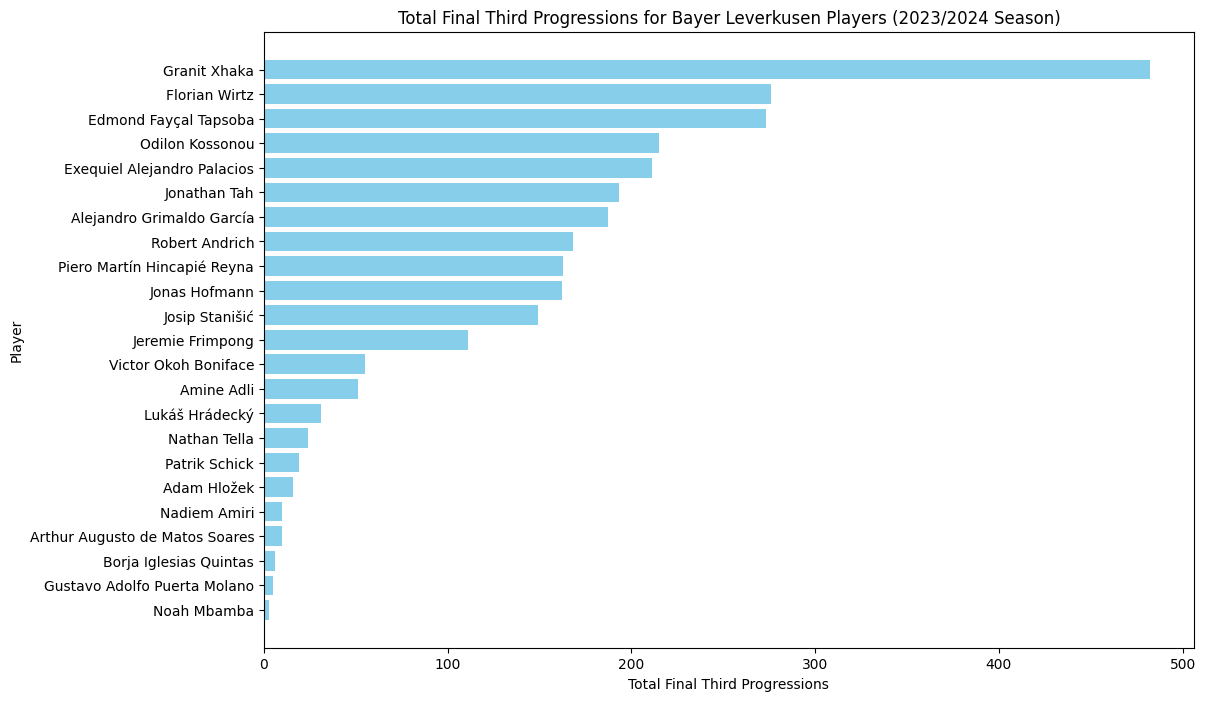

In [ ]:
# Plotting the data
plt.figure(figsize=(12, 8))
plt.barh(sorted_final_third_progressions['player'], sorted_final_third_progressions['total_progressions'], color='skyblue')
plt.xlabel('Total Final Third Progressions')
plt.ylabel('Player')
plt.title('Total Final Third Progressions for Bayer Leverkusen Players (2023/2024 Season)')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest values on top
plt.show()

In [ ]:
# Check unique values in the 'pass_outcome' column
unique_pass_outcomes = events_df['pass_outcome'].unique()
print("Unique values in 'pass_outcome':")
print(unique_pass_outcomes)

Unique values in 'pass_outcome':
[nan 'Incomplete' 'Pass Offside' 'Out' 'Unknown' 'Injury Clearance']


In [ ]:
# Count key passes and assists for Granit Xhaka
key_passes = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'] == 'Pass') & (events_df['pass_shot_assist'] == True)]
assists = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'] == 'Pass') & (events_df['pass_goal_assist'] == True)]

print(f"Key Passes for Granit Xhaka: {key_passes.shape[0]}")
print(f"Assists for Granit Xhaka: {assists.shape[0]}")

Key Passes for Granit Xhaka: 41
Assists for Granit Xhaka: 0


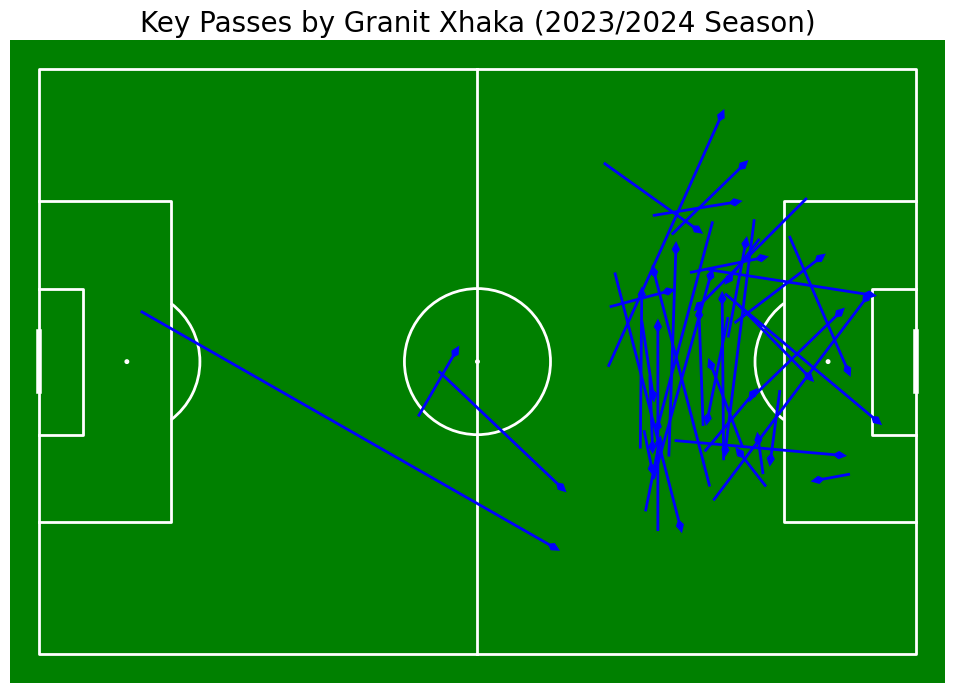

In [ ]:

# Set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# Plot key passes
for i, row in key_passes.iterrows():
    pitch.arrows(row['location'][0], row['location'][1], row['pass_end_location'][0], row['pass_end_location'][1],
                 ax=ax, color='blue', width=2, headwidth=3, headlength=3)

# Add title
ax.set_title('Key Passes by Granit Xhaka (2023/2024 Season)', fontsize=20)

# Show the plot
plt.show()

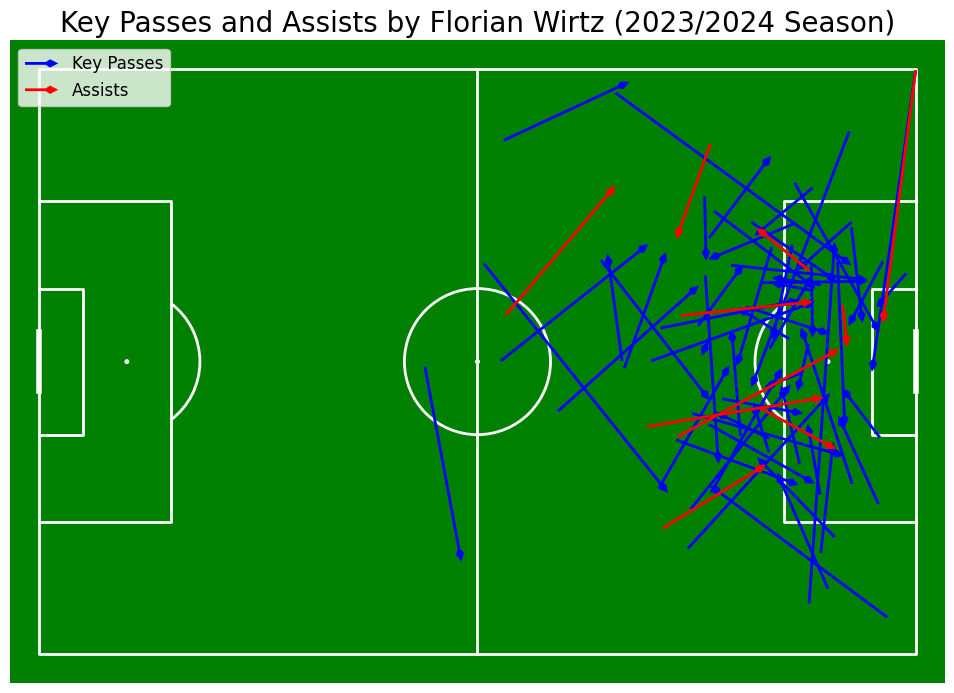

Key Passes for Florian Wirtz: 61
Assists for Florian Wirtz: 10


In [32]:
# Set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# Plot key passes
key_passes = pitch.arrows(key_passes_wirtz['location'].apply(lambda x: x[0]), 
                          key_passes_wirtz['location'].apply(lambda x: x[1]),
                          key_passes_wirtz['pass_end_location'].apply(lambda x: x[0]), 
                          key_passes_wirtz['pass_end_location'].apply(lambda x: x[1]),
                          ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Key Passes')

# Plot assists
assists = pitch.arrows(assists_wirtz['location'].apply(lambda x: x[0]), 
                       assists_wirtz['location'].apply(lambda x: x[1]),
                       assists_wirtz['pass_end_location'].apply(lambda x: x[0]), 
                       assists_wirtz['pass_end_location'].apply(lambda x: x[1]),
                       ax=ax, color='red', width=2, headwidth=3, headlength=3, label='Assists')

# Add title
ax.set_title('Key Passes and Assists by Florian Wirtz (2023/2024 Season)', fontsize=20)

# Add legend
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

# Print the counts
print(f"Key Passes for Florian Wirtz: {key_passes_wirtz.shape[0]}")
print(f"Assists for Florian Wirtz: {assists_wirtz.shape[0]}")

In [ ]:
# Filter key passes for Bayer Leverkusen players
bayer_leverkusen_key_passes = key_passes[key_passes['team'] == 'Bayer Leverkusen']

# Count the number of key passes by each Bayer Leverkusen player
bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes_count.sort_values(by='count', ascending=False)

# Display the sorted results
print(sorted_bayer_leverkusen_key_passes_count)

                            player  count
11                   Jonas Hofmann     69
1        Alejandro Grimaldo García     63
7                    Florian Wirtz     61
8                     Granit Xhaka     41
10                Jeremie Frimpong     36
6      Exequiel Alejandro Palacios     23
19                  Robert Andrich     19
2                       Amine Adli     17
15                    Nathan Tella     13
20            Victor Okoh Boniface     13
13                  Josip Stanišić     12
16                 Odilon Kossonou     11
17                   Patrik Schick      7
5            Edmond Fayçal Tapsoba      6
0                      Adam Hložek      6
4           Borja Iglesias Quintas      5
12                    Jonathan Tah      4
18     Piero Martín Hincapié Reyna      4
3   Arthur Augusto de Matos Soares      3
9     Gustavo Adolfo Puerta Molano      1
14                    Nadiem Amiri      1


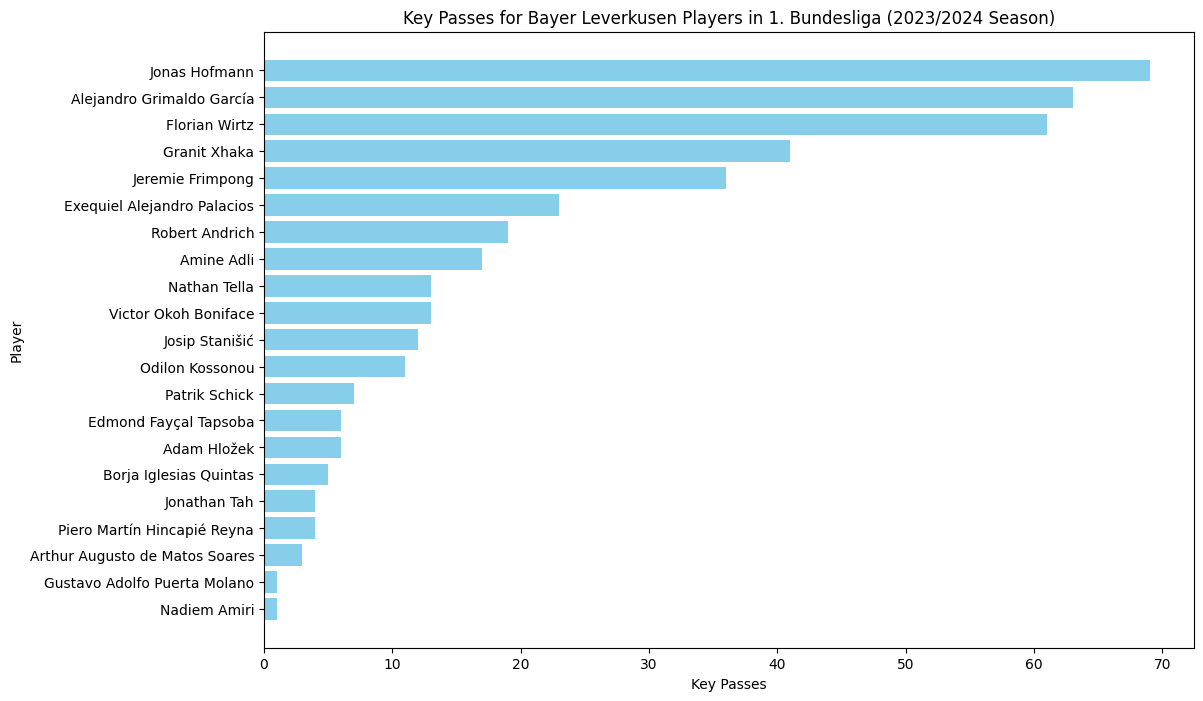

In [ ]:
# Plotting the data
plt.figure(figsize=(12, 8))
plt.barh(sorted_bayer_leverkusen_key_passes_count['player'], sorted_bayer_leverkusen_key_passes_count['count'], color='skyblue')
plt.xlabel('Key Passes')
plt.ylabel('Player')
plt.title('Key Passes for Bayer Leverkusen Players in 1. Bundesliga (2023/2024 Season)')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest values on top
plt.show()

In [ ]:

# Filter passes for Bayer Leverkusen players
bayer_leverkusen_passes = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')]

# Initialize a list to store the results
pass_accuracy_list = []

# Calculate pass accuracy for each player
for player in bayer_leverkusen_passes['player'].unique():
    player_passes = bayer_leverkusen_passes[bayer_leverkusen_passes['player'] == player]
    total_passes = player_passes.shape[0]
    successful_passes = player_passes[player_passes['pass_outcome'].isna()].shape[0]
    unsuccessful_passes = player_passes[~player_passes['pass_outcome'].isna()].shape[0]
    
    if total_passes > 0:
        pass_accuracy = successful_passes / total_passes * 100
        unsuccessful_pass_percentage = unsuccessful_passes / total_passes * 100
        pass_accuracy_list.append({
            'player': player,
            'total_passes': total_passes,
            'successful_passes': successful_passes,
            'unsuccessful_passes': unsuccessful_passes,
            'pass_accuracy': pass_accuracy,
            'unsuccessful_pass_percentage': unsuccessful_pass_percentage
        })

# Convert the list to a DataFrame
pass_accuracy_df = pd.DataFrame(pass_accuracy_list)

# Sort the DataFrame by pass accuracy in descending order
sorted_pass_accuracy_df = pass_accuracy_df.sort_values(by='pass_accuracy', ascending=False)

# Display the sorted results
print(sorted_pass_accuracy_df[['player', 'total_passes', 'successful_passes', 'unsuccessful_passes', 'pass_accuracy', 'unsuccessful_pass_percentage']])

                            player  total_passes  successful_passes  \
23                     Matěj Kovář            17                 17   
21                     Noah Mbamba            19                 19   
19    Gustavo Adolfo Puerta Molano            43                 41   
4                     Jonathan Tah          2167               2057   
22                    Nadiem Amiri            98                 91   
9      Piero Martín Hincapié Reyna          1423               1314   
15     Exequiel Alejandro Palacios          2022               1867   
6                     Granit Xhaka          3299               3045   
2            Edmond Fayçal Tapsoba          1946               1783   
5                  Odilon Kossonou          1422               1288   
3                   Robert Andrich          1501               1359   
20                  Josip Stanišić          1072                963   
18  Arthur Augusto de Matos Soares           108                 94   
17    

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Assuming we have the events_df from the previous data fetch

# Filter passes for Bayer Leverkusen players only
bayer_passes = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')]

# Calculate pass accuracy for each Bayer Leverkusen player
pass_accuracy_list = []

for player in bayer_passes['player'].unique():
    player_passes = bayer_passes[bayer_passes['player'] == player]
    total_passes = player_passes.shape[0]
    successful_passes = player_passes[player_passes['pass_outcome'].isna()].shape[0]
    
    if total_passes > 0:
        pass_accuracy = (successful_passes / total_passes) * 100
        pass_accuracy_list.append({
            'player': player,
            'total_passes': total_passes,
            'successful_passes': successful_passes,
            'pass_accuracy': pass_accuracy
        })

pass_accuracy_df = pd.DataFrame(pass_accuracy_list)

# 1. Set a minimum pass threshold (e.g., 100 passes)
min_passes = 100
filtered_df = pass_accuracy_df[pass_accuracy_df['total_passes'] >= min_passes]

# 2. Calculate confidence intervals
def confidence_interval(success, total, confidence=0.95):
    if total == 0:
        return 0, 0
    z = stats.norm.ppf((1 + confidence) / 2)
    p = float(success) / total
    se = np.sqrt(p * (1 - p) / total)
    return p - z * se, p + z * se

filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confidence_interval(row['successful_passes'], row['total_passes']), axis=1))

# 3. Calculate weighted average
total_passes = filtered_df['total_passes'].sum()
weighted_accuracy = (filtered_df['pass_accuracy'] * filtered_df['total_passes']).sum() / total_passes

# Sort by pass accuracy and reset index
filtered_df = filtered_df.sort_values('pass_accuracy', ascending=False).reset_index(drop=True)

# Display results
print("Pass Accuracy Comparison for Bayer Leverkusen Players (minimum {} passes):".format(min_passes))
print(filtered_df[['player', 'total_passes', 'pass_accuracy', 'ci_lower', 'ci_upper']])
print("\nWeighted Average Pass Accuracy for Bayer Leverkusen: {:.2f}%".format(weighted_accuracy))

Pass Accuracy Comparison for Bayer Leverkusen Players (minimum 100 passes):
                            player  total_passes  pass_accuracy  ci_lower  \
0                     Jonathan Tah          2167      94.923858  0.939996   
1      Piero Martín Hincapié Reyna          1423      92.340126  0.909583   
2      Exequiel Alejandro Palacios          2022      92.334322  0.911747   
3                     Granit Xhaka          3299      92.300697  0.913910   
4            Edmond Fayçal Tapsoba          1946      91.623844  0.903930   
5                  Odilon Kossonou          1422      90.576653  0.890582   
6                   Robert Andrich          1501      90.539640  0.890591   
7                   Josip Stanišić          1072      89.832090  0.880229   
8   Arthur Augusto de Matos Soares           108      87.037037  0.807021   
9                      Adam Hložek           155      84.516129  0.788212   
10                   Florian Wirtz          1841      83.813145  0.821306   


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_80401/758058569.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confidence_interval(row['successful_passes'], row['total_passes']), axis=1))
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_80401/758058569.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confide

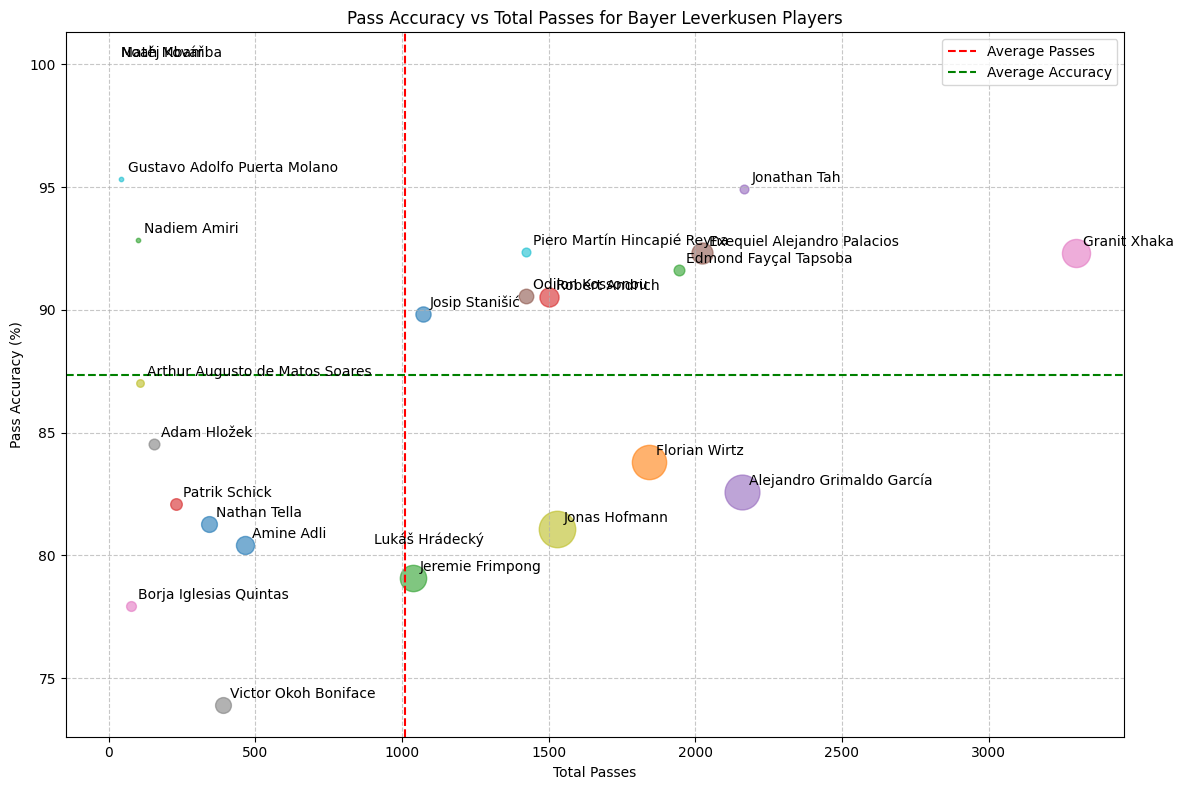

In [ ]:
# Merge the key passes count with our pass accuracy data
pass_accuracy_df = pd.merge(pass_accuracy_df, sorted_bayer_leverkusen_key_passes_count, on='player', how='left')

# Fill any NaN values in the 'count' column with 0
pass_accuracy_df['count'] = pass_accuracy_df['count'].fillna(0)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each player
for _, player in pass_accuracy_df.iterrows():
    ax.scatter(player['total_passes'], player['pass_accuracy'], 
               s=player['count']*10,  # Adjust size based on key passes count
               alpha=0.6)
    ax.annotate(player['player'], 
                (player['total_passes'], player['pass_accuracy']),
                xytext=(5, 5), textcoords='offset points')

# Set labels and title
ax.set_xlabel('Total Passes')
ax.set_ylabel('Pass Accuracy (%)')
ax.set_title('Pass Accuracy vs Total Passes for Bayer Leverkusen Players')

# Add a grid for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add a vertical line for average number of passes
avg_passes = pass_accuracy_df['total_passes'].mean()
ax.axvline(x=avg_passes, color='r', linestyle='--', label='Average Passes')

# Add a horizontal line for average pass accuracy
avg_accuracy = pass_accuracy_df['pass_accuracy'].mean()
ax.axhline(y=avg_accuracy, color='g', linestyle='--', label='Average Accuracy')

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
unique_event_types = events_df['type'].unique()
print("Unique event types:")
for event_type in sorted(unique_event_types):
    print(event_type)

Unique event types:
50/50
Bad Behaviour
Ball Receipt*
Ball Recovery
Block
Carry
Clearance
Dispossessed
Dribble
Dribbled Past
Duel
Error
Foul Committed
Foul Won
Goal Keeper
Half End
Half Start
Injury Stoppage
Interception
Miscontrol
Offside
Own Goal Against
Own Goal For
Pass
Player Off
Player On
Pressure
Referee Ball-Drop
Shield
Shot
Starting XI
Substitution
Tactical Shift


In [ ]:
# Define defensive actions
defensive_actions = ['Pressure', 'Interception', 'Ball Recovery', 'Block', 'Clearance', 'Duel']

# Filter Xhaka's defensive actions
xhaka_defensive_actions = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'].isin(defensive_actions))]

# Count each type of defensive action
action_counts = xhaka_defensive_actions['type'].value_counts()

print("Granit Xhaka's Defensive Actions:")
print(action_counts)

# Calculate total defensive actions
total_defensive_actions = action_counts.sum()
print(f"\nTotal Defensive Actions: {total_defensive_actions}")

Granit Xhaka's Defensive Actions:
type
Pressure         309
Ball Recovery    191
Duel              69
Block             65
Clearance         46
Interception      18
Name: count, dtype: int64

Total Defensive Actions: 698


Defensive Actions by Bayer Leverkusen Players:
type                            Ball Recovery  Block  Clearance  Duel  \
player                                                                  
Adam Hložek                                20      7          3    17   
Alejandro Grimaldo García                 158     66         43    65   
Amine Adli                                 38     19          7    36   
Arthur Augusto de Matos Soares              8      5          7     7   
Borja Iglesias Quintas                      7      2          1    11   
Edmond Fayçal Tapsoba                     136     37         71    64   
Exequiel Alejandro Palacios               136     39         23    68   
Florian Wirtz                             161     58          4    69   
Granit Xhaka                              191     65         46    69   
Gustavo Adolfo Puerta Molano                2      2          1     5   
Jeremie Frimpong                          111     54         18    45   
Jona

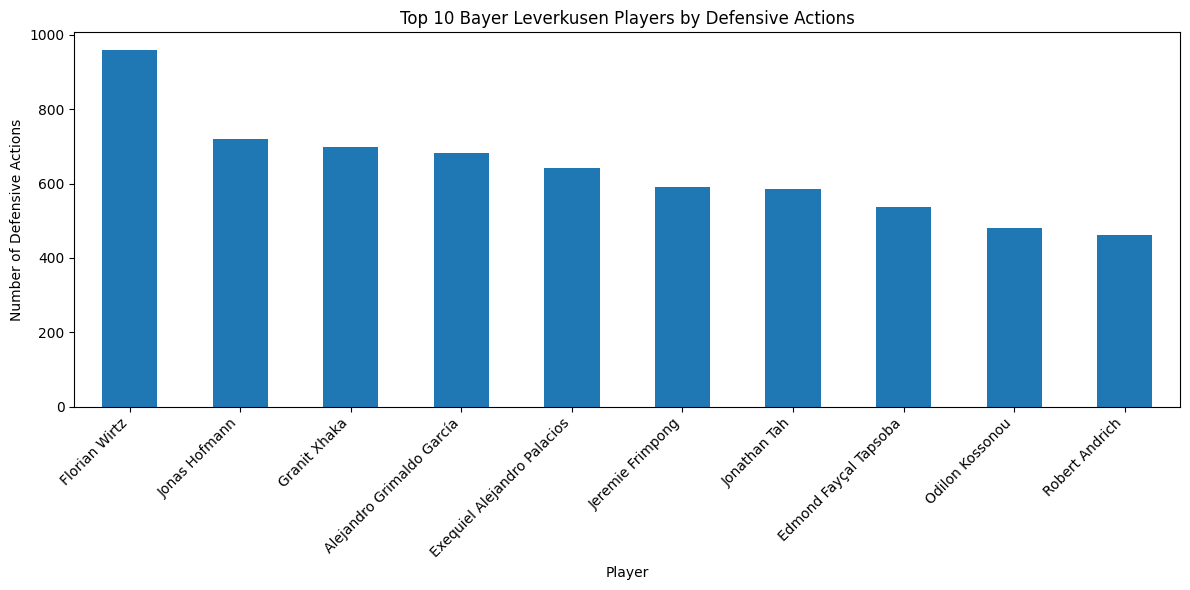

In [ ]:
# Define defensive actions
defensive_actions = ['Pressure', 'Interception', 'Ball Recovery', 'Block', 'Clearance', 'Duel']

# Filter defensive actions for all Bayer Leverkusen players
leverkusen_defensive_actions = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'].isin(defensive_actions))]

# Group by player and count each type of defensive action
player_action_counts = leverkusen_defensive_actions.groupby('player')['type'].value_counts().unstack(fill_value=0)

# Calculate total defensive actions for each player
player_total_actions = player_action_counts.sum(axis=1).sort_values(ascending=False)

# Display the results
print("Defensive Actions by Bayer Leverkusen Players:")
print(player_action_counts)

print("\nTotal Defensive Actions by Player:")
print(player_total_actions)

# Calculate and display team totals
team_totals = player_action_counts.sum()
print("\nTeam Totals for Each Defensive Action:")
print(team_totals)
print(f"\nTotal Team Defensive Actions: {team_totals.sum()}")

# Highlight Granit Xhaka's stats
if 'Granit Xhaka' in player_total_actions:
    xhaka_total = player_total_actions['Granit Xhaka']
    xhaka_rank = player_total_actions.rank(ascending=False)['Granit Xhaka']
    print(f"\nGranit Xhaka's Total Defensive Actions: {xhaka_total}")
    print(f"Rank among Bayer Leverkusen players: {xhaka_rank:.0f}")

# Visualize top 10 players by total defensive actions
plt.figure(figsize=(12, 6))
player_total_actions.head(10).plot(kind='bar')
plt.title("Top 10 Bayer Leverkusen Players by Defensive Actions")
plt.xlabel("Player")
plt.ylabel("Number of Defensive Actions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [90]:
# Filter for Bayer Leverkusen's starting lineups
bayer_starting_lineups = events_df[(events_df['type'] == 'Starting XI') & (events_df['team'] == 'Bayer Leverkusen')]

# Extract formations
bayer_formations = bayer_starting_lineups['tactics'].apply(lambda x: x['formation'] if isinstance(x, dict) else None)

print("Starting formations used by Bayer Leverkusen:")
print(bayer_formations.value_counts())

# Calculate the total number of matches
total_matches = len(bayer_formations)

# Calculate the percentage for each formation
formation_percentages = (bayer_formations.value_counts() / total_matches * 100).round(2)

print("\nPercentage of matches for each formation:")
for formation, percentage in formation_percentages.items():
    print(f"{formation}: {percentage}%")

print(f"\nTotal matches analyzed: {total_matches}")

Starting formations used by Bayer Leverkusen:
tactics
3421    25
343      8
3412     1
Name: count, dtype: int64

Percentage of matches for each formation:
3421: 73.53%
343: 23.53%
3412: 2.94%

Total matches analyzed: 34


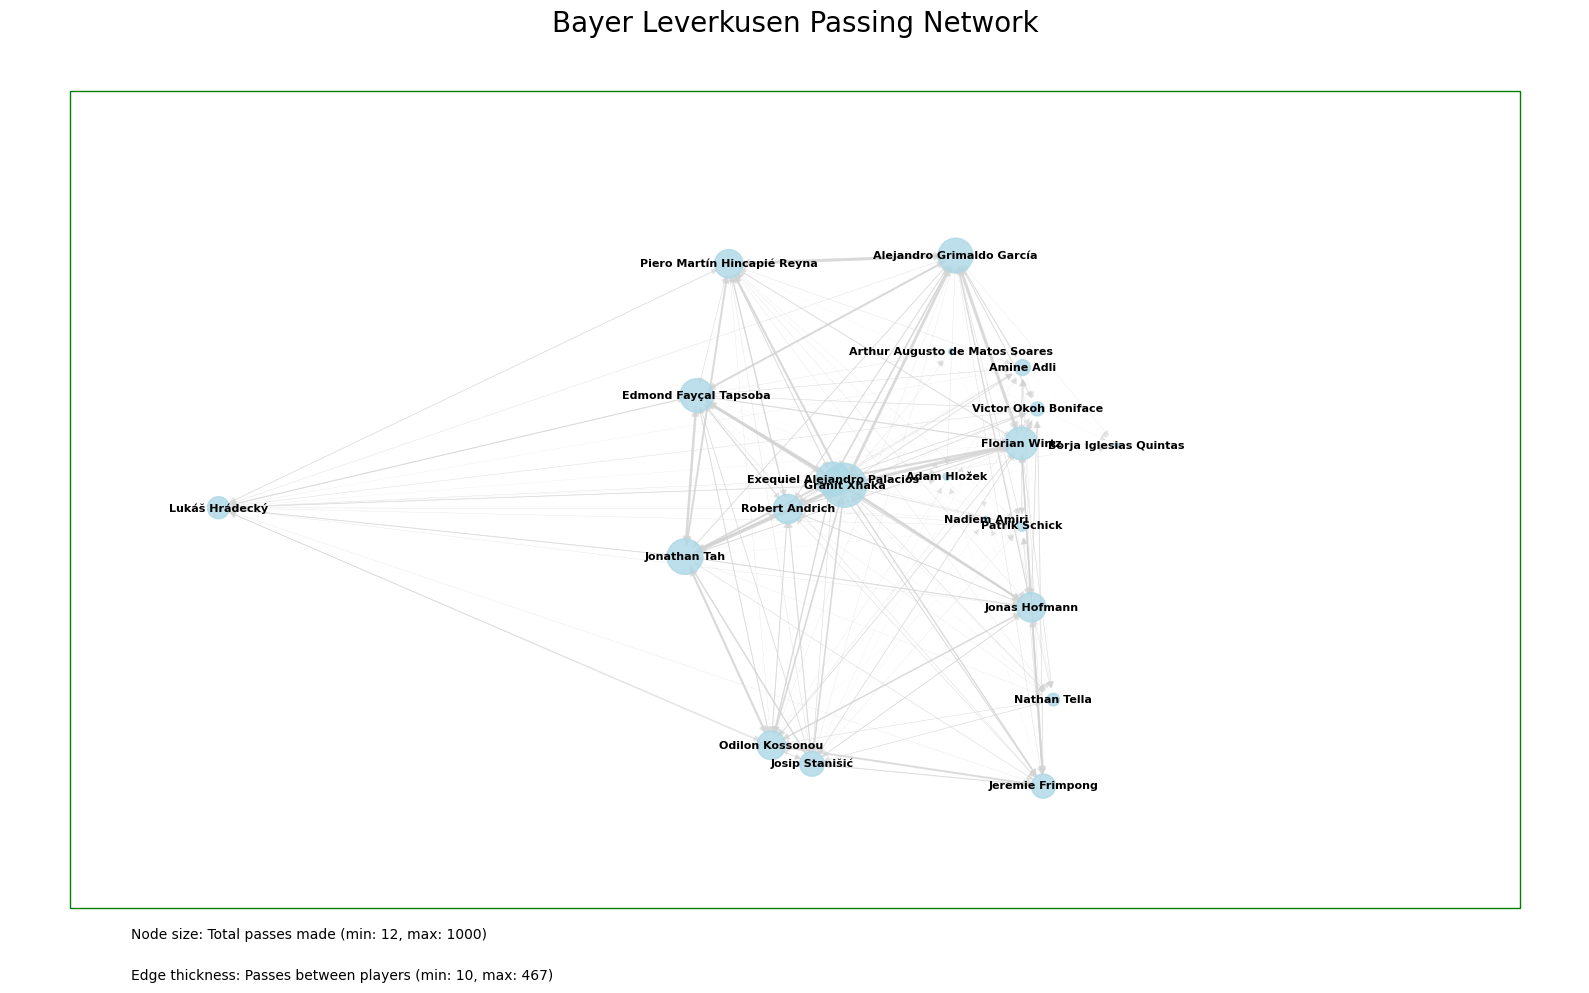


Top 5 passers:
Granit Xhaka: 3280 passes
Jonathan Tah: 2143 passes
Alejandro Grimaldo García: 2044 passes
Exequiel Alejandro Palacios: 1990 passes
Edmond Fayçal Tapsoba: 1900 passes

Top 5 pass combinations:
Exequiel Alejandro Palacios to Granit Xhaka: 467 passes
Granit Xhaka to Florian Wirtz: 393 passes
Jonathan Tah to Granit Xhaka: 385 passes
Alejandro Grimaldo García to Florian Wirtz: 370 passes
Granit Xhaka to Exequiel Alejandro Palacios: 356 passes


In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter passes for Bayer Leverkusen players
bayer_passes = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')]

# 2. Create a DataFrame with pass connections
pass_connections = bayer_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')

# 3. Create a directed graph
G = nx.DiGraph()

# 4. Add nodes and edges (filter for significant connections)
min_passes = 10  # Adjust this threshold as needed
for _, row in pass_connections.iterrows():
    if row['pass_count'] >= min_passes:
        G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])

# 5. Calculate node sizes based on total passes made
node_sizes = dict(G.out_degree(weight='weight'))
max_passes = max(node_sizes.values())
node_sizes = {player: (count / max_passes) * 1000 for player, count in node_sizes.items()}

# 6. Calculate node positions based on average player locations
player_positions = bayer_passes.groupby('player')['location'].apply(lambda x: np.mean(x.tolist(), axis=0)).to_dict()
pos = {player: (loc[0], 80 - loc[1]) for player, loc in player_positions.items() if player in G.nodes()}

# 7. Create the plot
plt.figure(figsize=(16, 10))

# 8. Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_edge_weight = max(edge_weights)
nx.draw_networkx_edges(G, pos, width=[w / max_edge_weight * 3 for w in edge_weights], 
                       alpha=0.6, edge_color='lightgray', arrows=True, arrowsize=10)

# 9. Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=[node_sizes[node] for node in G.nodes()], 
                       node_color='lightblue', alpha=0.8)

# 10. Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# 11. Add a pitch outline
pitch_outline = plt.Rectangle((0, 0), 120, 80, fill=False, color='green')
plt.gca().add_patch(pitch_outline)

# 12. Customize the plot
plt.title("Bayer Leverkusen Passing Network", fontsize=20)
plt.xlim(-5, 125)
plt.ylim(-5, 85)
plt.axis('off')

# 13. Add a legend
plt.text(5, -3, f"Node size: Total passes made (min: {min(node_sizes.values()):.0f}, max: {max(node_sizes.values()):.0f})")
plt.text(5, -7, f"Edge thickness: Passes between players (min: {min_passes}, max: {max_edge_weight})")

plt.tight_layout()
plt.show()

# 14. Print top passers and pass combinations
top_passers = sorted(node_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 passers:")
for player, size in top_passers:
    print(f"{player}: {G.out_degree(player, weight='weight')} passes")

top_combinations = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print("\nTop 5 pass combinations:")
for passer, receiver, data in top_combinations:
    print(f"{passer} to {receiver}: {data['weight']} passes")

In [40]:
# Assuming events_df contains StatsBomb event data
# First, let's check if position information is available
if 'position' in events_df.columns:
    # Extract unique player-position pairs
    player_positions = events_df[['player', 'position']].drop_duplicates().set_index('player')['position'].to_dict()
else:
    print("Position information not available in the dataset. Using fallback method.")
    # Use our fallback method if position data is not available
    player_positions = {player: infer_position(loc[0]) for player, loc in player_positions.items() if player in G.nodes()}
    # Assign goalkeeper manually
    goalkeeper = min(pos, key=lambda k: pos[k][0])
    player_positions[goalkeeper] = 'Goalkeeper'


In [41]:
# Assuming events_df contains StatsBomb event data
# First, let's check if position information is available
if 'position' in events_df.columns:
    # Extract unique player-position pairs
    player_positions = events_df[['player', 'position']].drop_duplicates().set_index('player')['position'].to_dict()
else:
    print("Position information not available in the dataset. Using fallback method.")
    # Use our fallback method if position data is not available
    player_positions = {player: infer_position(loc[0]) for player, loc in player_positions.items() if player in G.nodes()}
    # Assign goalkeeper manually
    goalkeeper = min(pos, key=lambda k: pos[k][0])
    player_positions[goalkeeper] = 'Goalkeeper'

# Map StatsBomb positions to our simplified categories
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender',
    'Left Back': 'Defender',
    'Center Back': 'Defender',
    'Right Wing Back': 'Defender',
    'Left Wing Back': 'Defender',
    'Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder',
    'Right Midfield': 'Midfielder',
    'Left Midfield': 'Midfielder',
    'Attacking Midfield': 'Midfielder',
    'Right Wing': 'Forward',
    'Left Wing': 'Forward',
    'Center Forward': 'Forward',
    'Secondary Striker': 'Forward'
}

# Apply the mapping
player_positions = {player: position_mapping.get(pos, 'Midfielder') for player, pos in player_positions.items()}

In [42]:
position_related_columns = [col for col in events_df.columns if 'position' in col.lower()]
print("Columns potentially related to position:", position_related_columns)

Columns potentially related to position: ['goalkeeper_position', 'position']


In [44]:
if 'position' in events_df.columns:
    print("\nUnique values in the 'position' column:")
    unique_positions = events_df['position'].unique()
    for position in unique_positions:
        if isinstance(position, str):
            print(position)
        elif isinstance(position, dict):
            print(f"Dictionary: {position}")
        elif pd.isna(position):
            print("NaN (missing value)")
        else:
            print(f"Other type: {type(position)} - {position}")
else:
    print("\nNo 'position' column found in the dataset.")


Unique values in the 'position' column:
NaN (missing value)
Right Center Forward
Left Center Forward
Center Back
Right Center Back
Right Wing Back
Goalkeeper
Left Center Back
Left Defensive Midfield
Right Defensive Midfield
Center Forward
Left Wing Back
Right Center Midfield
Right Attacking Midfield
Left Center Midfield
Left Attacking Midfield
Center Defensive Midfield
Center Attacking Midfield
Right Back
Left Back
Right Wing
Left Wing
Right Midfield
Left Midfield


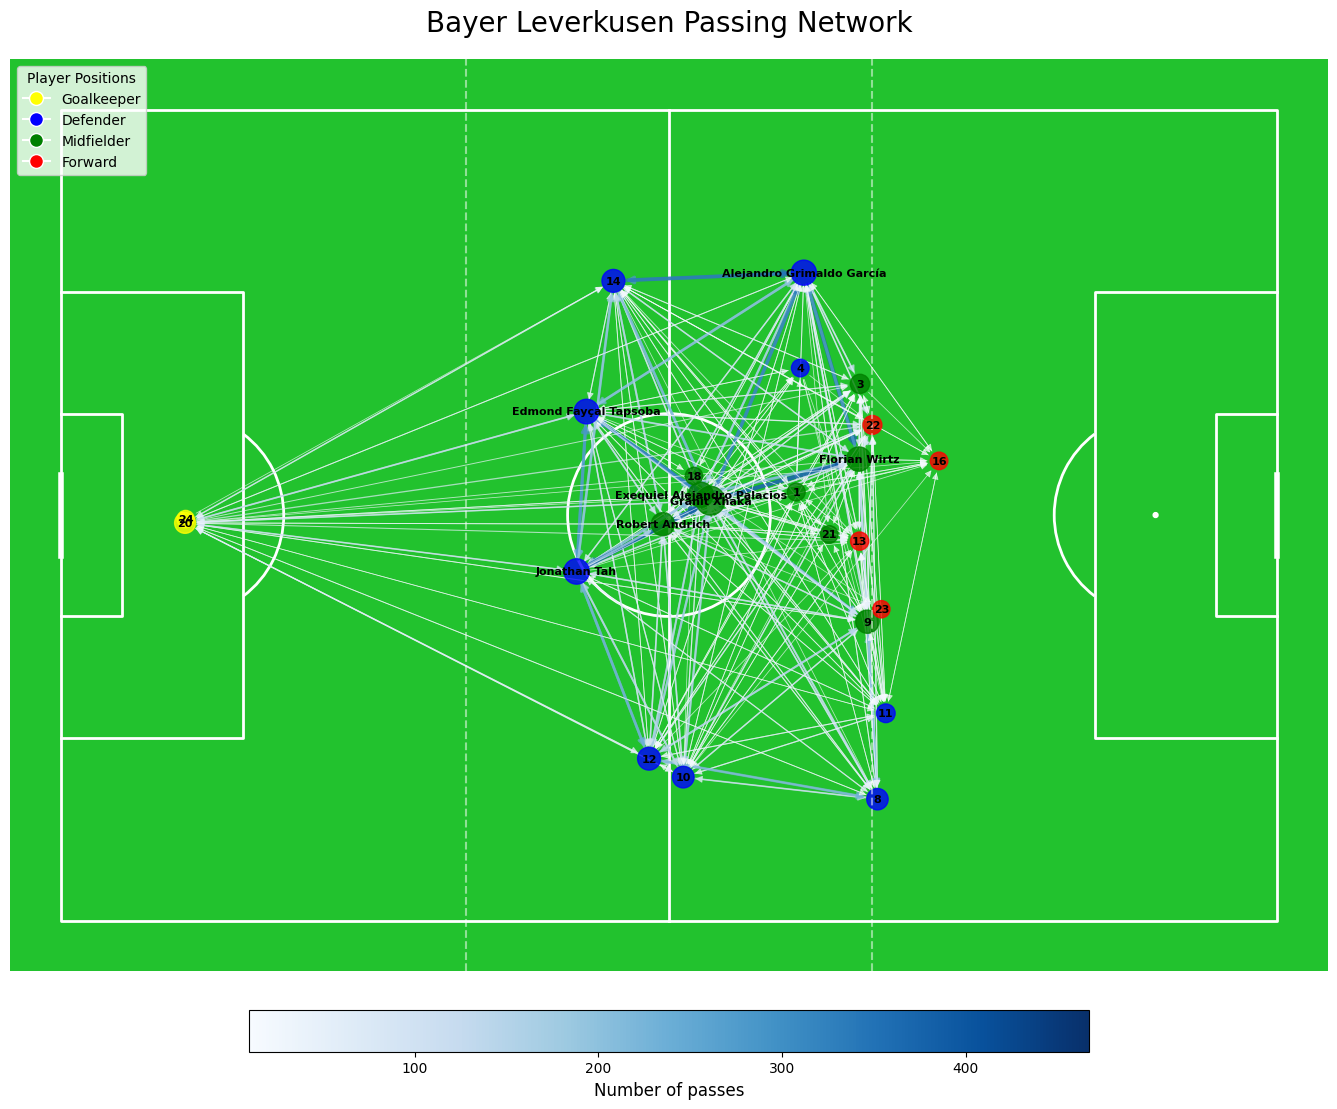


Top 7 passers:
Granit Xhaka (): 3280 passes
Jonathan Tah (): 2143 passes
Alejandro Grimaldo García (): 2053 passes
Exequiel Alejandro Palacios (): 1998 passes
Edmond Fayçal Tapsoba (): 1913 passes
Florian Wirtz (): 1805 passes
Robert Andrich (): 1472 passes

Top 5 pass combinations:
Exequiel Alejandro Palacios () to Granit Xhaka (): 467 passes
Granit Xhaka () to Florian Wirtz (): 393 passes
Jonathan Tah () to Granit Xhaka (): 385 passes
Alejandro Grimaldo García () to Florian Wirtz (): 370 passes
Granit Xhaka () to Exequiel Alejandro Palacios (): 356 passes


In [48]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch

# ... (previous data preparation code remains the same)

# Increase minimum passes threshold
min_passes = 10

# Get top passers
top_passers = sorted(node_sizes.items(), key=lambda x: x[1], reverse=True)[:7]
top_passer_names = [player for player, _ in top_passers]

# Create a mapping of player names to numbers for non-top passers
player_numbers = {player: str(i+1) for i, player in enumerate(G.nodes()) if player not in top_passer_names}

# Adjust node sizes to be more proportional
max_node_size = 1000
min_node_size = 100
node_sizes = {player: (count / max_passes) * (max_node_size - min_node_size) + min_node_size for player, count in node_sizes.items()}

# Create the plot
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white', stripe=False)
fig, ax = plt.subplots(figsize=(16, 11), constrained_layout=True)
pitch.draw(ax=ax)

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(edge_weights)
edge_widths = [(w / max_weight) * 3 + 0.5 for w in edge_weights]

edges = nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Blues,
    edge_vmin=min_passes,
    edge_vmax=max_weight,
    width=edge_widths,
    alpha=0.7, arrows=True, arrowsize=10
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[node_sizes[node] for node in G.nodes()],
    node_color=node_colors,
    alpha=0.8
)

# Draw labels
labels = {}
for node in G.nodes():
    if node in top_passer_names:
        labels[node] = node
    else:
        labels[node] = player_numbers[node]

nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8, font_weight='bold')

# Customize the plot
ax.set_title("Bayer Leverkusen Passing Network", fontsize=20, pad=20)
ax.set_xlim(-5, 125)
ax.set_ylim(-5, 85)

# Add vertical lines to divide the pitch into thirds
ax.axvline(x=40, color='white', linestyle='--', alpha=0.5)
ax.axvline(x=80, color='white', linestyle='--', alpha=0.5)

# Add a colorbar for edge weights
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min_passes, vmax=max_weight))
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Number of passes', fontsize=12)

# Add a legend for node colors
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=pos,
                              markerfacecolor=color, markersize=10)
                   for pos, color in position_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', title='Player Positions')

plt.show()

# Print top passers and pass combinations
print("\nTop 7 passers:")
for player, size in top_passers:
    print(f"{player} ({player_numbers.get(player, '')}): {G.out_degree(player, weight='weight')} passes")

top_combinations = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print("\nTop 5 pass combinations:")
for passer, receiver, data in top_combinations:
    print(f"{passer} ({player_numbers.get(passer, '')}) to {receiver} ({player_numbers.get(receiver, '')}): {data['weight']} passes")